# Модель хищник-жертва

## Описание модели

Рассмотрим систему, описывающую взаимодействие хищников и жертв, выраженную следующим образом:

- **V**: численность жертв
- **P**: численность хищников 

## Уравнения

Система уравнений может быть записана следующим образом:



\begin{align*}
\frac{dV}{dt} & = (a - bP)V \\
\frac{dP}{dt} & = (-c + kV)P
\end{align*}


где:
- **a** - скорость размножения жертв
- **b** - вероятность смерти жертвы от хищника
- **c** - вероятность убыли хищников при нехватке еды
- **k** - вероятность достаточности еды для размножения хищников

## Начальные условия

- \(V(0) = V_0\) - начальная численность жертв
- \(P(0) = P_0\) - начальная численность хищников

## Решение

Для начала подключим необходимые пакеты

In [92]:
import numpy as np
import matplotlib.pyplot as plt

А после зададим параметры и начальные условия модели

In [93]:
a = 0.1  # скорость размножения жертв
b = 0.02 # вероятность смерти жертвы от хищника
c = 0.3  # вероятность убыли хищников при нехватке еды
k = 0.01 # вероятность достаточности еды для размножения хищников

V0 = 40  # начальное число жертв
P0 = 9   # начальное число хищников
t0 = 0   # начальное время
tf = 200 # конечное время
dt = 0.1 # шаг по времени

Определим систему уравнений

In [94]:
def equations(V, P):
    V_derivative_1 = (a - b * P) * V
    P_derivative_1 = (-c + k * V) * P
    return np.array([V_derivative_1, P_derivative_1])

Для численного решения используем метод Рунге-Кутты 4-го порядка

In [95]:
def runge_kutta_4th_order(V0, P0, t0, tf, dt):
    # Число шагов
    N = int((tf - t0) / dt) + 1
    t = np.linspace(t0, tf, N)
    V = np.zeros(N)
    P = np.zeros(N)

    V[0] = V0
    P[0] = P0

    for i in range(1, N):
        k1 = equations(V[i-1], P[i-1])
        k2 = equations(V[i-1] + 0.5 * dt * k1[0], P[i-1] + 0.5 * dt * k1[1])
        k3 = equations(V[i-1] + 0.5 * dt * k2[0], P[i-1] + 0.5 * dt * k2[1])
        k4 = equations(V[i-1] + dt * k3[0], P[i-1] + dt * k3[1])

        V[i] = V[i-1] + (dt / 6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        P[i] = P[i-1] + (dt / 6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])

    return t, V, P

# Выполнение численного решения
t, V, P = runge_kutta_4th_order(V0, P0, t0, tf, dt)

Визуализируем полученные результаты

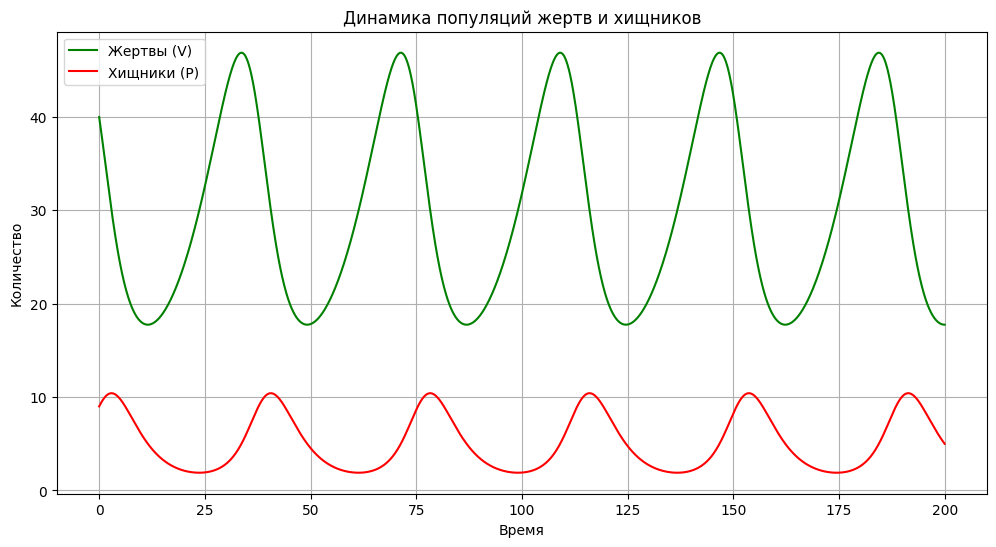

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(t, V, label='Жертвы (V)', color='green')
plt.plot(t, P, label='Хищники (P)', color='red')
plt.title('Динамика популяций жертв и хищников')
plt.xlabel('Время')
plt.ylabel('Количество')
plt.legend()
plt.grid()
plt.show()

Найдем стационарные точки

In [97]:
def find_equilibrium(a, b, c, k):
    V = 0  # тривиальная точка
    P1 = a / b  # первая ненулевая стационарная точка
    V1 = (c / (k * (a / b))) if k * (a / b) != 0 else 0  # вычисление V при P = a/b
    return (V, P1), (V1, P1)

equilibrium_points = find_equilibrium(a, b, c, k)

Построим фазовую диаграмму с отмеченными стационарными точками

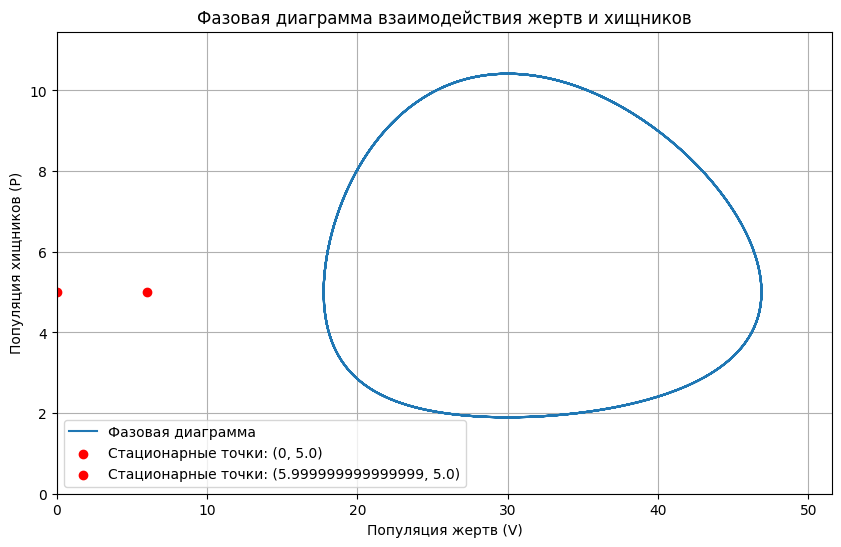

In [98]:
plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Фазовая диаграмма')
plt.title('Фазовая диаграмма взаимодействия жертв и хищников')
plt.xlabel('Популяция жертв (V)')
plt.ylabel('Популяция хищников (P)')
for point in equilibrium_points:
    plt.scatter(point[0], point[1], color='red', label=f'Стационарные точки: ({point[0]}, {point[1]})')
plt.xlim(0, max(V) * 1.1)
plt.ylim(0, max(P) * 1.1)
plt.grid()
plt.legend()
plt.show()